In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
RAW_DIR = Path.cwd().parent / "data" / "raw"

In [2]:
nav_history = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv")
fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
transactions = pd.read_csv(PROCESSED_DIR / "clean_transactions.csv")
performance = pd.read_csv(PROCESSED_DIR / "clean_performance.csv")
aum = pd.read_csv(RAW_DIR / "03_aum_by_fund_house.csv")
sip = pd.read_csv(RAW_DIR / "04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(RAW_DIR / "05_category_inflows.csv")
folios = pd.read_csv(RAW_DIR / "06_industry_folio_count.csv")
holdings = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])

print("All datasets loaded.")

All datasets loaded.


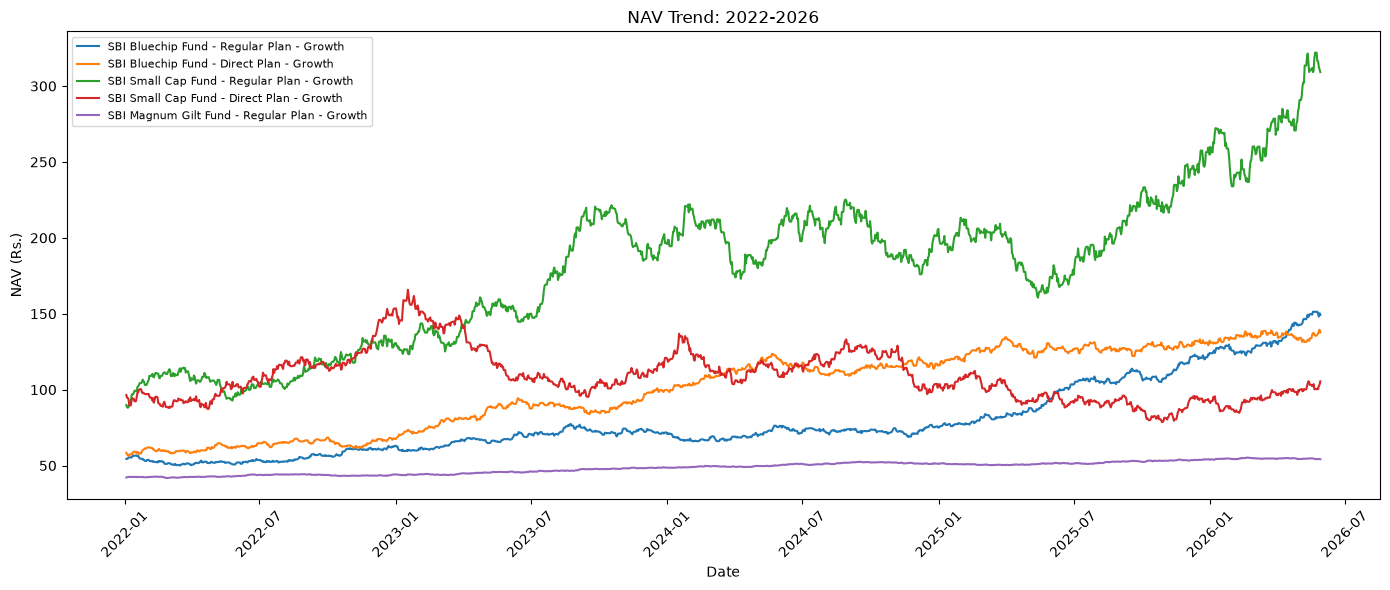

In [3]:
top_funds = fund_master["amfi_code"].head(5).tolist()

plt.figure(figsize=(14, 6))
for code in top_funds:
    fund_data = nav_history[nav_history["amfi_code"].astype(str) == str(code)]
    fund_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    plt.plot(fund_data["date"], fund_data["nav"], label=fund_name)

plt.title("NAV Trend: 2022-2026")
plt.xlabel("Date")
plt.ylabel("NAV (Rs.)")
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

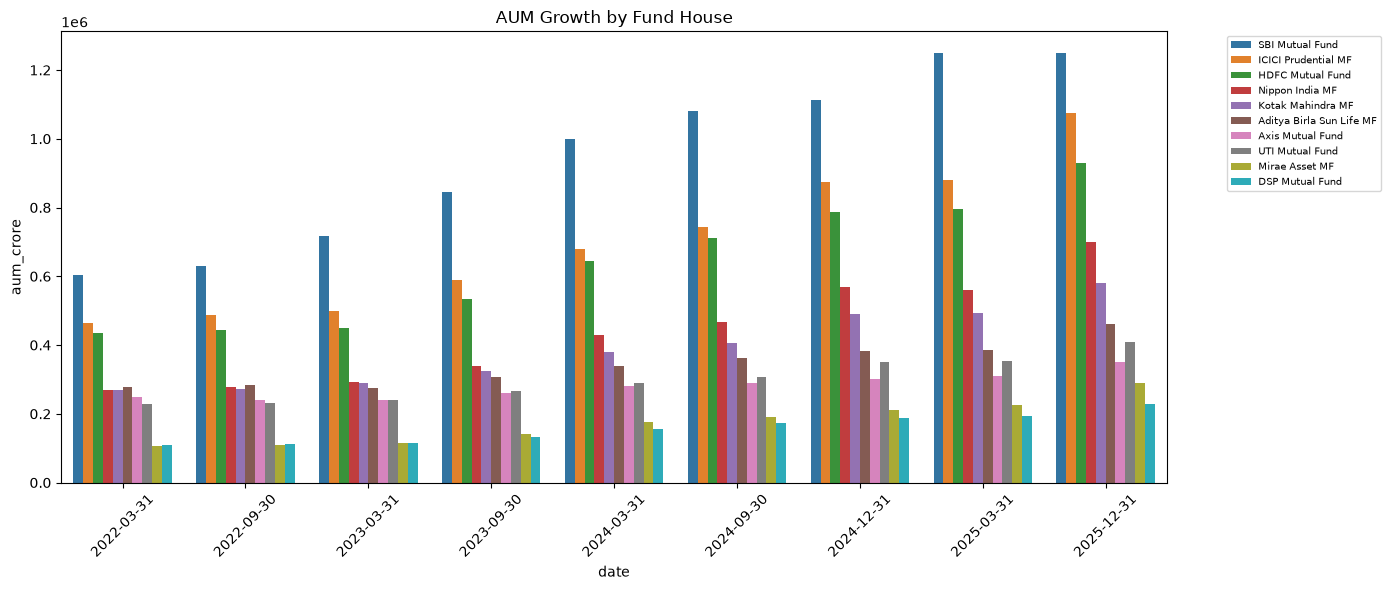

In [4]:
plt.figure(figsize=(14, 6))
sns.barplot(data=aum, x="date", y="aum_crore", hue="fund_house")
plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

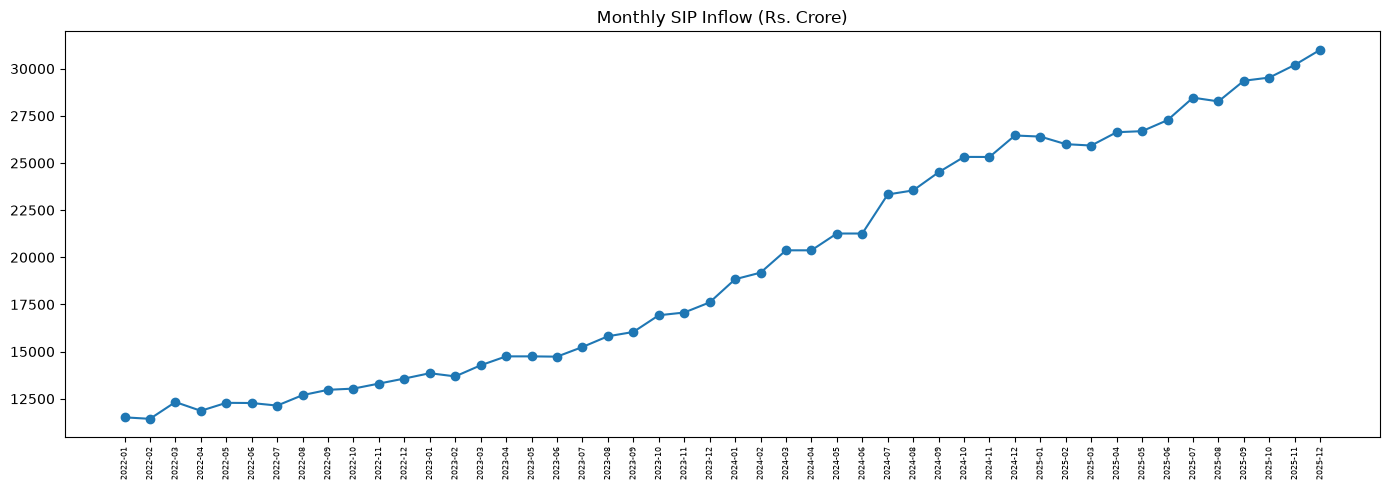

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")
plt.title("Monthly SIP Inflow (Rs. Crore)")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

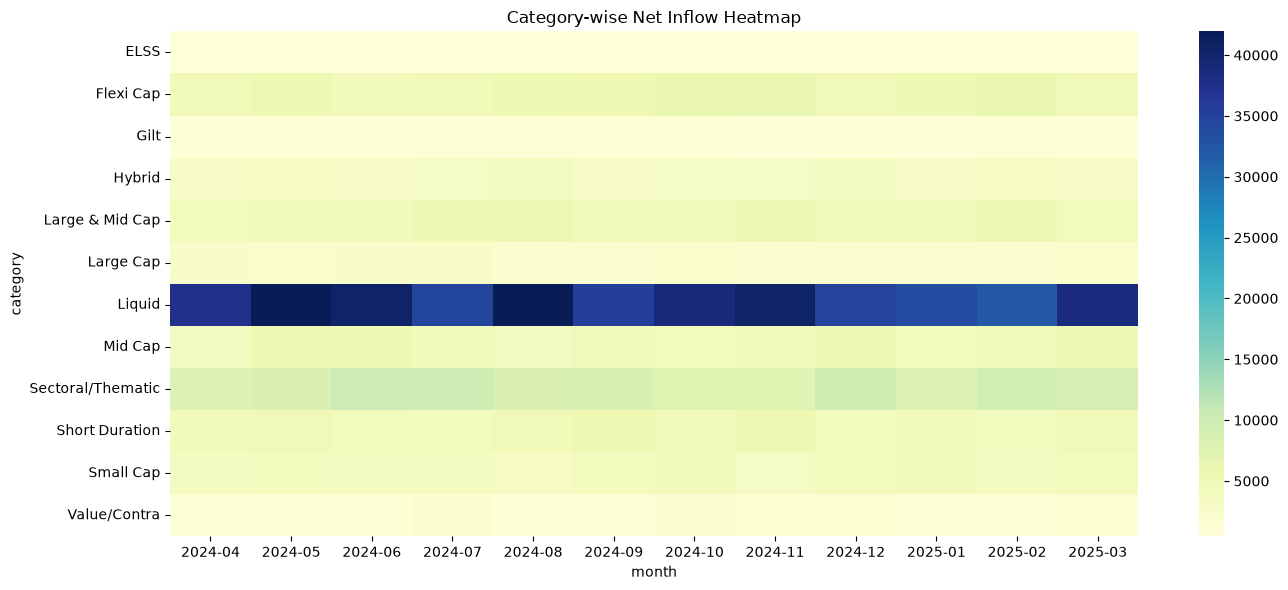

In [6]:
heatmap_data = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False)
plt.title("Category-wise Net Inflow Heatmap")
plt.tight_layout()
plt.show()

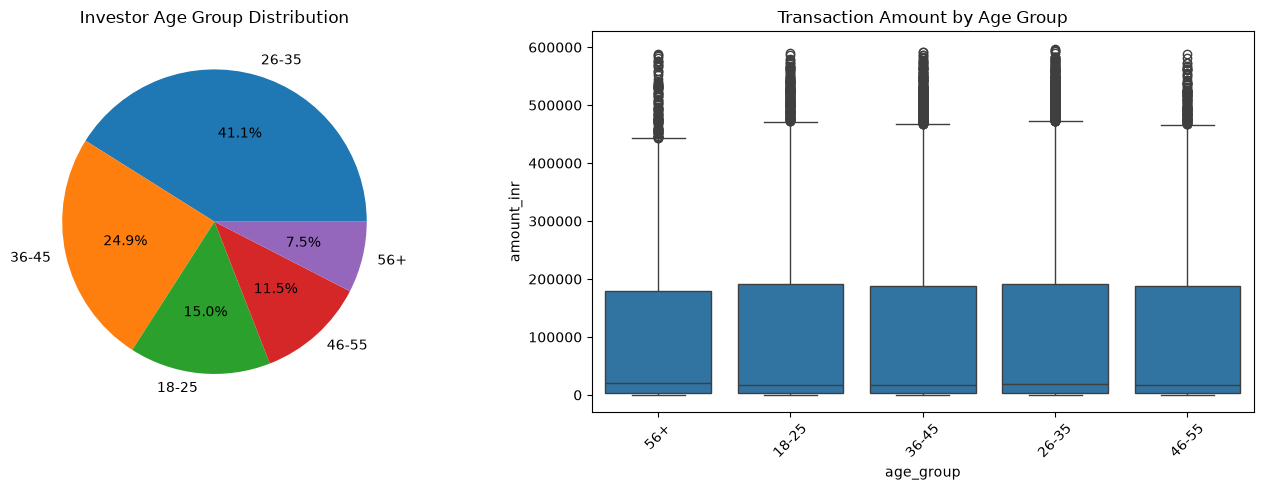

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = transactions["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
axes[0].set_title("Investor Age Group Distribution")

sns.boxplot(data=transactions, x="age_group", y="amount_inr", ax=axes[1])
axes[1].set_title("Transaction Amount by Age Group")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

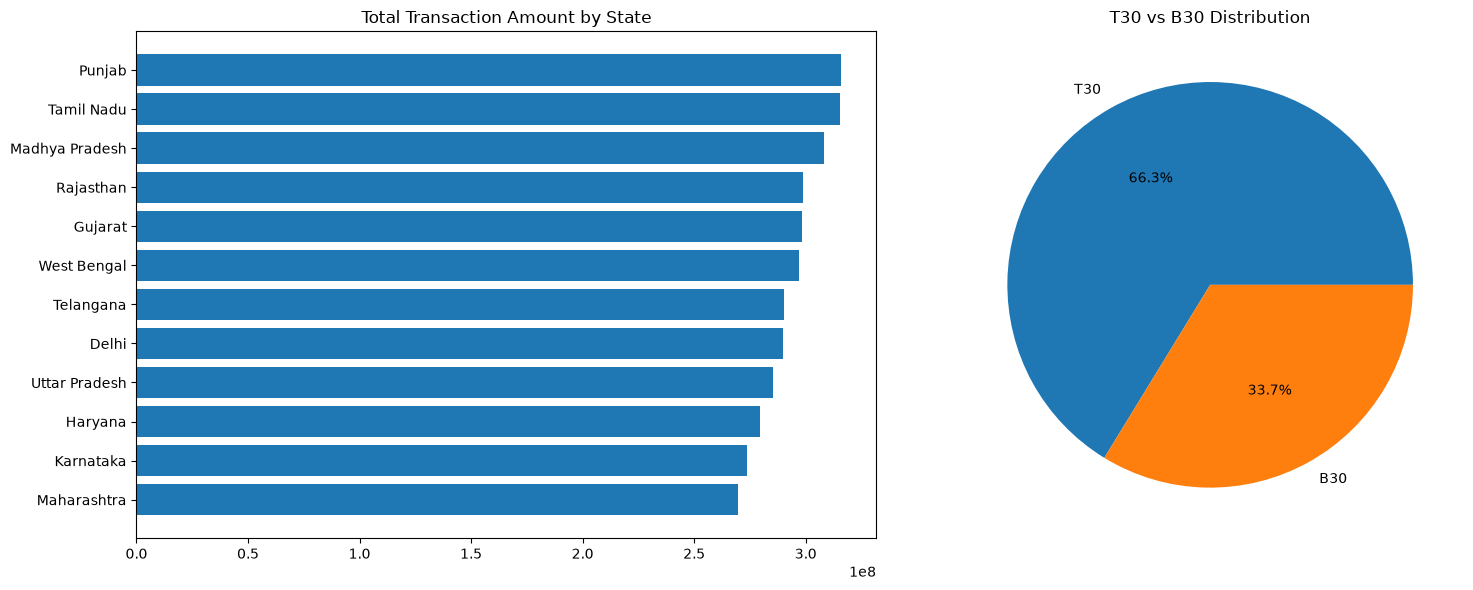

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_totals = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False)
axes[0].barh(state_totals.index, state_totals.values)
axes[0].set_title("Total Transaction Amount by State")
axes[0].invert_yaxis()

tier_counts = transactions["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%")
axes[1].set_title("T30 vs B30 Distribution")

plt.tight_layout()
plt.show()

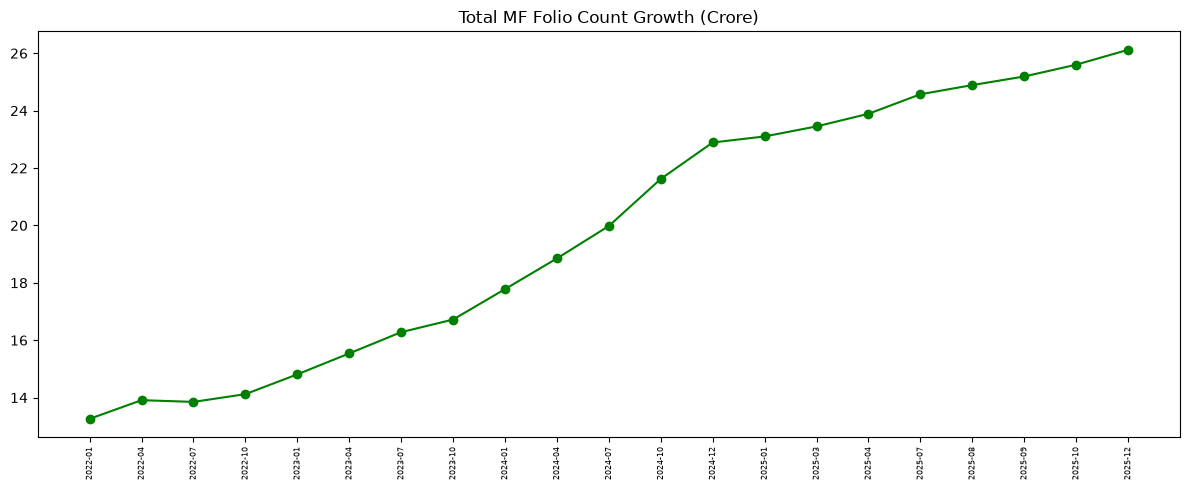

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(folios["month"], folios["total_folios_crore"], marker="o", color="green")
plt.title("Total MF Folio Count Growth (Crore)")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

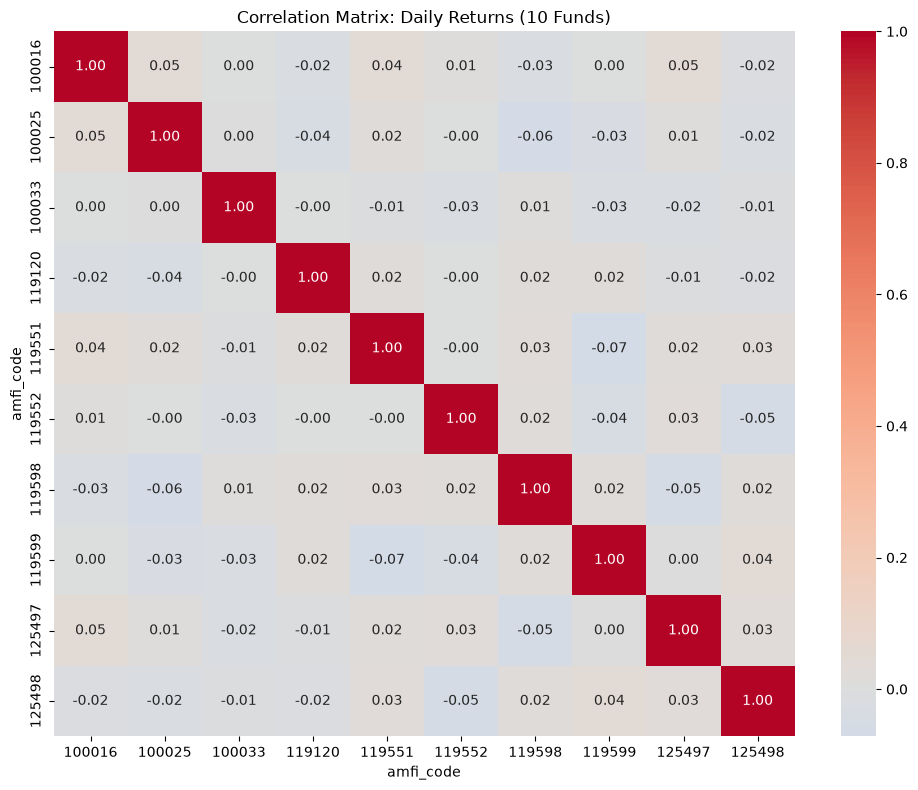

In [10]:
top10_codes = fund_master["amfi_code"].head(10).tolist()
nav_pivot = nav_history[nav_history["amfi_code"].astype(str).isin([str(c) for c in top10_codes])]
nav_pivot = nav_pivot.pivot(index="date", columns="amfi_code", values="nav")

returns = nav_pivot.pct_change().dropna()
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix: Daily Returns (10 Funds)")
plt.tight_layout()
plt.show()

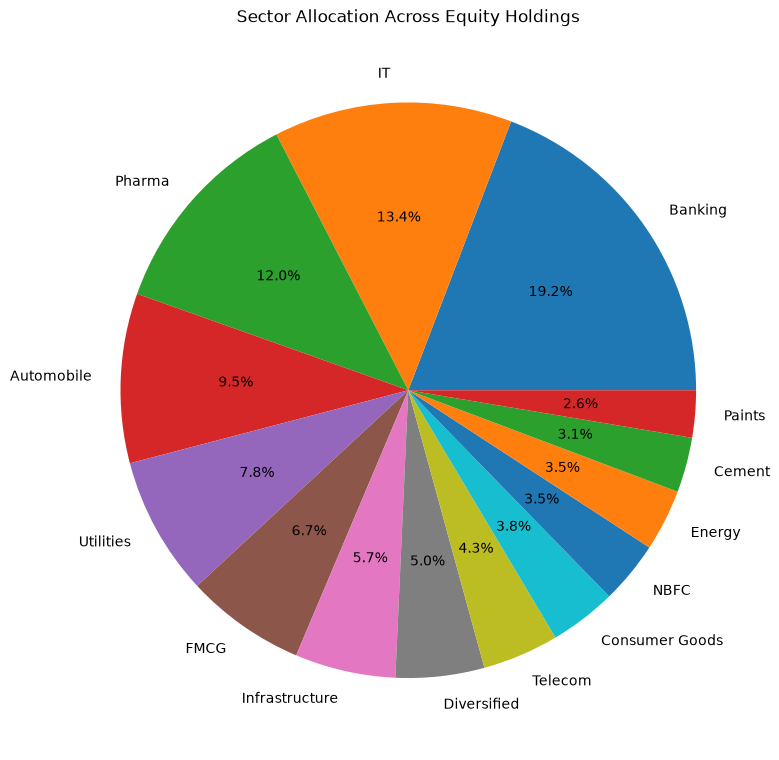

In [11]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%")
plt.title("Sector Allocation Across Equity Holdings")
plt.tight_layout()
plt.show()

## Key EDA Findings

1. **NAV trends:** All 5 SBI funds trended upward from 2022 to 2026. SBI Small Cap Fund (green) grew the most and was also the most volatile, rising from ~100 to over 300 with sharp swings. SBI Magnum Gilt (purple) was the flattest and most stable, staying under 60 throughout — as expected for a debt/gilt fund versus an equity small-cap fund.

2. **AUM growth:** SBI Mutual Fund had the largest AUM by far across every quarter, growing from ~0.6 lakh crore (Mar 2022) to ~1.25 lakh crore (late 2025) — roughly doubling. ICICI Prudential MF was consistently second-largest. DSP Mutual Fund had the smallest AUM among the 10 fund houses shown.

3. **SIP inflows:** Monthly SIP inflows show a clear, steady upward trend across the whole period — from ~₹11,500 crore in Jan 2022 to over ₹31,000 crore by the end of 2025, with a noticeably steeper climb from mid-2024 onward.

4. **Category inflows:** The Liquid category stands out sharply with the highest net inflows by a wide margin (darkest blue band across every month) — all other categories (Equity sub-categories, Gilt, Hybrid, etc.) show comparatively low, pale inflows throughout.

5. **Sector allocation:** Portfolio holdings are most concentrated in Banking and IT/Technology sectors, which together make up the largest slices of the sector allocation pie chart, followed by Pharma.

6. **Correlation:** The correlation matrix shows a mix of positive and negative relationships